<a href="https://www.nvidia.com/dli"> <img src="images/nvidia_header.png" style="margin-left: -30px; width: 300px; float: left;"> </a>

# Deploying a RAG Pipeline with NVIDIA NIMs

Welcome to the next notebook in the **NVIDIA AI-Q Research Assistant Blueprint** Deep Learning Institute (DLI) course!

In the previous notebook, you learned how to deploy and interact with NVIDIA's reasoning models. Now you'll take the next critical step: **connecting those models to knowledge sources** through Retrieval-Augmented Generation (RAG). While reasoning models are powerful, they can only draw from what they learned during training. RAG solves this by allowing models to access up-to-date, domain-specific information from your own documents.

## Video Walkthrough

Execute the cell below to load the video of instructor Edward Li working through this notebook.

In [ ]:
%%html
<video controls width="800">
 <source src="https://d36m44n9vdbmda.cloudfront.net/assets/s-fx-40-v1/03-deploy-rag-v1.mp4" type="video/mp4">
 <track src="transcripts/03-deploy-rag-transcript.vtt"
       kind="subtitles" srclang="en" label="English" default>
 Sorry, your browser does not support embedded videos.
</video>

## 🎯 Learning Objectives

By the end of this notebook, you will:

1. **Understand RAG Fundamentals**: Learn what RAG is, why it's essential, and how it addresses LLM limitations
2. **Master RAG Architecture**: Explore the components of a complete RAG system (ingestion, retrieval, generation)
3. **Deploy NVIDIA's RAG Blueprint**: Set up a production-ready RAG pipeline using NVIDIA-hosted endpoints
4. **Learn the APIs**: Ingest documents and query the system programmatically using the ingestion and retrieval APIs
5. **Understand Retrieval & Reranking**: See how semantic search and reranking improve answer quality

## 📦 The Blueprint: Build an Enterprise RAG Pipeline

This notebook guides you through deploying a complete enterprise-grade RAG system powered by NVIDIA NIM:

**Core Components:**
- **NeMo Retriever Embedding NIM**: Converts text into vector embeddings for semantic search
- **NeMo Retriever Reranking NIM**: Improves retrieval accuracy by reordering search results
- **Nemotron Reasoning NIM**: The language model that generates final answers grounded in citations
- **Milvus Vector Database**: Stores and searches document embeddings at scale
- **Document Ingestion Service**: Processes PDFs, images, and multimodal content
- **RAG Query Server**: Orchestrates the entire retrieval and generation workflow

## 📖 Table of Contents

| Section | Topic | Learning Goals |
|-------------------------|----------------------|----------------------|
| **1** | What is Retrieval-Augmented Generation (RAG)? | Understand what RAG systems are and how they work  |
| **2** | Deploy RAG with NVIDIA-Hosted Endpoints | Use NVIDIA-hosted endpoints to deploy the RAG Blueprint |
| **3** | Learning the Ingestion API | Test deployment and learn how to ingest documents programmatically |
| **4** | Sample Workflow: RAG-On vs. RAG-Off | Explore the impact RAG makes on improving response quality |
| **5** | Understanding Document Retrieval and Reranking | Explore under-the-hood processes that enable RAG |
| **6** | (Optional) Local / On-Prem Deployment | Learn how to transition from hosted to local endpoints |

---

## 1. What is Retrieval-Augmented Generation (RAG)?

**Retrieval-Augmented Generation (RAG)** is a powerful AI architecture that combines the reasoning capabilities of large language models with the ability to access external knowledge sources. Instead of relying solely on information learned during training, RAG systems retrieve relevant context from documents, databases, or knowledge bases before generating responses.

This notebook will guide you through deploying NVIDIA's [Enterprise RAG Blueprint](https://build.nvidia.com/nvidia/build-an-enterprise-rag-pipeline), taking you from deployment to hands-on interaction with a production-ready RAG system.

### 1.1 Motivation

While large language models (LLMs) demonstrate impressive capabilities, they face significant limitations when deployed in real-world enterprise scenarios. **Retrieval-Augmented Generation (RAG)** addresses these challenges by augmenting LLMs with external knowledge retrieval, creating a more robust and reliable AI system.

#### Limitations of Traditional LLMs vs. How RAG Solves Them

| **Limitation** | **Traditional LLM Challenge** | **How RAG Addresses It** |
|----------------|-------------------------------|--------------------------|
| **Static Pretrained Knowledge** | LLMs are frozen at their training cutoff date and cannot learn new information without expensive retraining. They lack knowledge of events, products, or developments that occurred after training. | RAG retrieves current information from updated knowledge bases in real-time, allowing the system to access the latest information without retraining the model. |
| **No Access to Private/Proprietary Data** | LLMs only know what was in their public training data. They cannot access company-specific documents, internal policies, customer records, or proprietary databases. | RAG connects to your private document stores, databases, and knowledge bases, enabling the LLM to generate responses grounded in your organization's specific data. |
| **Hallucination and Factual Errors** | When LLMs don't know an answer, they often generate plausible-sounding but incorrect information ("hallucinations") based on patterns in training data. | RAG grounds responses in retrieved source documents, significantly reducing hallucinations by providing factual context. Responses can be verified against source material. |
| **Lack of Source Attribution** | Traditional LLMs often generate answers without citing sources, making it difficult to verify information or understand where knowledge came from. | RAG systems return the source documents used to generate each response, enabling full transparency and fact-checking. |
| **Domain-Specific Knowledge Gaps** | General-purpose LLMs may lack deep expertise in specialized domains (legal, medical, engineering, etc.) or use outdated terminology. | RAG retrieves from domain-specific knowledge bases, allowing the system to leverage specialized, expert-curated content for accurate responses. |
| **Context Window Limitations** | LLMs have fixed context windows and cannot process entire document repositories or large knowledge bases at once. | RAG uses semantic search to find and retrieve only the most relevant information, efficiently working with massive knowledge bases beyond any context window. |

By combining the language understanding and generation capabilities of LLMs with information retrieval, RAG creates AI systems that are more accurate, trustworthy, and applicable to real-world enterprise use cases.


### 1.2 Key Components of a RAG system

The Enterprise RAG Blueprint follows a two-phase architecture: **Extraction** and **Retrieval**.

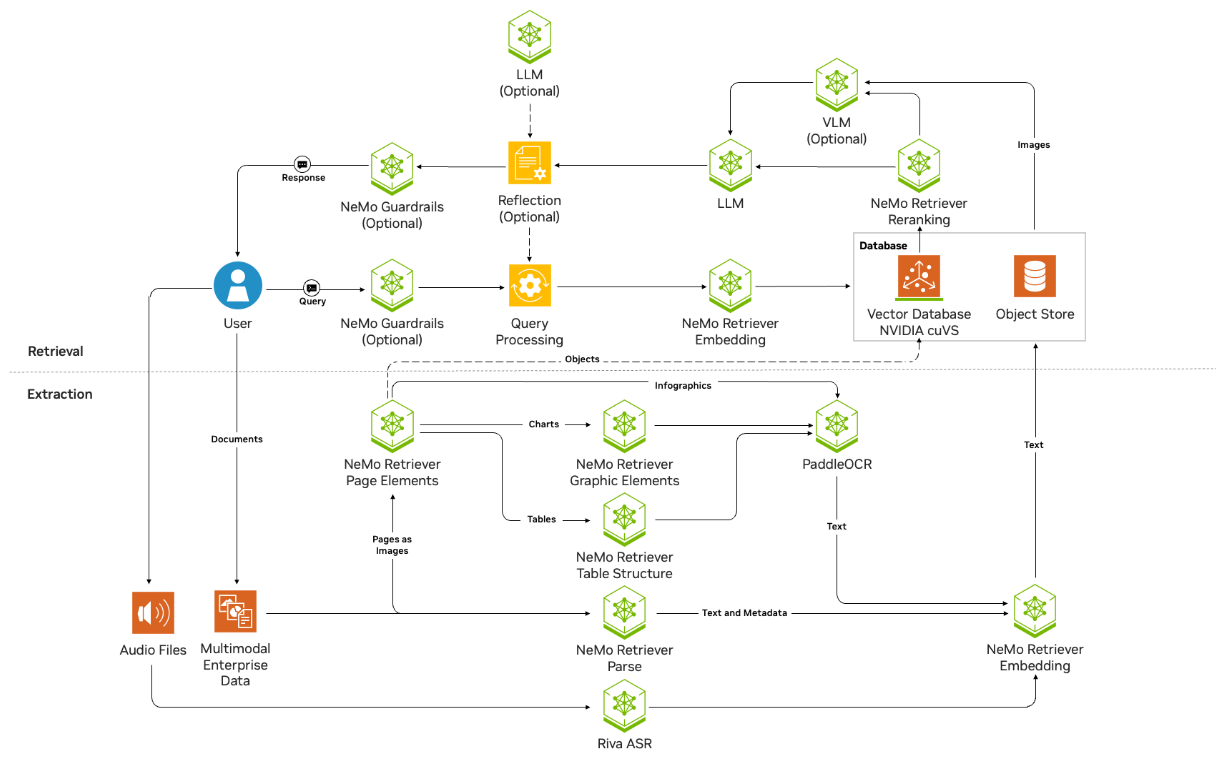

#### 1.2.1 Extraction Phase: Document Ingestion and Processing

The extraction phase collects and processes data and converts it into a numerical vector embedding format which can be understood by the model. These vector embeddings capture the semantic meaning of the content in high-dimensional space such that two close, or "similar", vectors in the vector space have their corresponding document chunks being similar in semantic meaning. Similarly, two distant vectors in that vector space have their document chunks being dissimilar to each other in semantic meaning. These vectors are then stored in a vector database for later retrieval. 

- **Multimodal Document Parsing**: NeMo Retriever, which handles the embedding and retrieval steps, supports the following data types:
  - **Text content** from documents using intelligent parsing
  - **Tables** with structure preservation for accurate data retrieval
  - **Charts and infographics** with visual understanding capabilities
  - **Images** extracted as separate elements

- **Embedding Generation**: All extracted content (text, tables, images, etc.) is converted into **vector embeddings** (an array of numbers representing its meaning) using NeMo Retriever Embedding models. 

- **Vector Storage**: Embeddings are stored in a **vector database** optimized for fast similarity search

#### 1.2.2 Retrieval Phase: Query Processing and Response Generation

Both the uploaded documents and the user query to the RAG pipeline are encoded as vectors (an array of numbers representing its meaning) through an embedding process. This enables efficient similarity search based on semantic meaning rather than simple keyword matching. The system then calculates similarity scores between that query vector and all pre-stored document vectors already in the database to find which documents are mathematically closest (and thus which documents are semantically closest in meaning to the user query). The top-ranking chunks are retrieved based on this semantic proximity in vector space—meaning you'll get relevant results about "PC optimization" even if you searched for "speed up computer" because the concepts are semantically related despite different wording. Finally, these retrieved chunks are forwarded to the LLM as additional context to provide a more accurate and well-grounded final response to the user.

When a user submits a query, the system follows this pipeline:

1. **Query Guardrails** *(Optional)*: NeMo Guardrails can filter inappropriate queries and ensure safe inputs before processing.

2. **Query Embedding**: The user's question is converted into a vector embedding using the same embedding model as the one used for document extraction and ingestion, enabling semantic similarity matching.

3. **Semantic Retrieval**: The query embedding is compared against the vector database to retrieve the most semantically similar content chunks, regardless of exact keyword matches.

4. **Intelligent Reranking**: NeMo Retriever Reranking takes the chunks obtained by semantic retrieval and reorders them to prioritize the chunks most relevant to the specific query.

5. **LLM Response Generation**: The LLM receives the reranked context along with the original query and generates a comprehensive, grounded response.

6. **Multimodal Enhancement** *(Optional)*: 
   - **Vision Language Models (VLM)** can process retrieved images to provide visual understanding to the LLM before generating a response to the user. 
   - **Reflection mechanisms** can refine and validate responses for improved quality

7. **Response Guardrails** *(Optional)*: Final responses can be validated through guardrails for content safety and on-topic relevance before being returned to the user.

This architecture enables the RAG system to understand complex multimodal documents, retrieve relevant information with semantic precision, and generate accurate responses grounded in your specific knowledge base.

---

## 2. Deploy the RAG Blueprint with NVIDIA-Hosted Endpoints

Now that you understand what RAG is and how it works, let's deploy a complete RAG system! We'll use **Docker Compose** to orchestrate multiple microservices that work together to provide document ingestion and retrieval capabilities.

### Deployment Overview

In this section, we'll deploy the NVIDIA RAG Blueprint using a **hybrid approach**:

✅ **NVIDIA-Hosted NIMs**: We'll use free, GPU-accelerated endpoints from NVIDIA for the compute-intensive models (embeddings, reranking, LLM generation)  
✅ **Local Docker Containers**: We'll run supporting infrastructure locally (vector database, orchestration services)

**Why This Approach?**

| Component | Where It Runs | Reason |
|-----------|---------------|--------|
| Milvus Vector Database | Local (Docker) | Your data stays on your infrastructure |
| Ingestor & RAG Servers | Local (Docker) | Orchestration logic runs close to your data |
| Embedding/Reranking NIMs | NVIDIA-Hosted Endpoint | Free GPU acceleration without local GPU requirements |
| Document Processing NIMs | NVIDIA-Hosted Endpoint | Free GPU acceleration without local GPU requirements |
| Nemotron LLM | NVIDIA-Hosted Endpoint | Access powerful reasoning models without infrastructure costs |

This hybrid model is ideal for quick development and prototyping especially in compute-limited situations. For production deployment with full data sovereignty, see the [Appendix](#Appendix:-Local-/-On-Prem-Deployment) for on-premises instructions.

### What We'll Deploy

The deployment includes **8 microservices** total:

**Infrastructure Layer:**

1. **Milvus Standalone**: Vector database for embeddings
2. **MinIO**: Object storage for Milvus
3. **etcd**: Metadata store for Milvus
4. **Redis**: Cache for logs, chat history, etc

**Processing Layer:**

5. **NV-Ingest Runtime**: Multimodal document extraction
6. **Ingestor Server**: Document upload and ingestion API

**RAG Layer:**

7. **RAG Server**: Query and retrieval orchestration API
8. **RAG Playground**: Web interface for chatting and testing

The following cells will guide you through each deployment step. 

### 2.1 Clone the GitHub Repository

First, we'll clone the official NVIDIA RAG Blueprint repository. This repository contains:
- **Source Code** for defining each stage of the pipeline
- **Docker Compose** for starting all microservices
- **Environment templates** for environment configuration
- **Sample data** for testing the deployed pipeline
- **Documentation** for learning more about the Blueprint

The repository is located at: https://github.com/NVIDIA-AI-Blueprints/rag.git

Run the cell below to clone the repository to your local environment:

In [ ]:
!git clone https://github.com/NVIDIA-AI-Blueprints/rag.git && cd rag && git checkout f0af4a2

In [ ]:
import os
os.chdir('rag')

### 2.2 Set Up Your NGC API Key

Just like in Notebook 1, you'll need an NVIDIA NGC API key to access the hosted NIM endpoints. This same key will also authenticate Docker to pull container images from NVIDIA's registry.

**You should already have an NGC API key from the Prerequisites Notebook**, you can use it here!

#### Setting the API Key

Run the cell below to securely input your NGC API key. The code will:
- Check if a key is already set in your environment
- Prompt you to enter it securely if not (your key won't be displayed in the output)
- Validate that it's a properly formatted NGC key
- Store it for use throughout this notebook

**Security Note**: Your API key is like a password—never share it publicly or commit it to version control!

In [ ]:
import getpass

# Step 1: Set API key in notebook environment
if not os.environ.get("NGC_API_KEY", "").startswith("nvapi-"):
    nvapi_key = getpass.getpass("Enter your NGC API key: ")
    assert nvapi_key.startswith("nvapi-"), f"{nvapi_key[:5]}... is not a valid key"
    os.environ["NGC_API_KEY"] = nvapi_key
    print("✅ API key has been set in notebook environment")

### 2.3 Authenticate Docker with NGC

Before we can deploy the blueprint, Docker needs permission to pull container images from NVIDIA's registry (`nvcr.io`). We'll use your NGC API key to authenticate.

**What's happening:**
- `docker login nvcr.io`: Authenticates with NVIDIA's container registry
- Username is always `$oauthtoken` (a special placeholder for API key authentication)
- Your NGC API key serves as the password

Run the cell below to authenticate Docker:

In [ ]:
!echo "${NGC_API_KEY}" | docker login nvcr.io -u '$oauthtoken' --password-stdin

### 2.4 Configure Deployment for NVIDIA-Hosted Endpoints

Before deploying the services, we need to configure the system to use NVIDIA's hosted endpoints instead of running all NIMs locally. This next cell sets up environment variables that tell our local services where to find the cloud-hosted models.

**Configuration Overview:**

The cell below will:
1. **Set Model Names**: Specify which NVIDIA models to use for LLM, embeddings, and reranking
2. **Configure Endpoints**: Point to NVIDIA's hosted API endpoints instead of local services
3. **Set Service URLs**: Configure document processing services (OCR, object detection)
4. **Disable Reranking** (optional): For faster responses during testing

**Key Models We're Using:**

| Model Type | Model Name | Purpose |
|------------|------------|---------|
| **LLM** | `llama-3.3-nemotron-super-49b-v1.5` | Answer generation with reasoning |
| **Embedding** | `llama-3.2-nv-embedqa-1b-v2` | Convert text to 2048-dim vectors |
| **Reranking** | `llama-3.2-nv-rerankqa-1b-v2` | Improve retrieval relevance |

**Document Processing NIMs:**
- **PaddleOCR**: Extract text from images and scanned PDFs
- **YOLOX Page Elements**: Detect and extract page structure
- **YOLOX Graphics**: Identify charts, diagrams, and figures
- **YOLOX Table Structure**: Parse table layouts

All of these NIMs are hosted by NVIDIA and accessed via free API endpoints!

Review and source `deploy/compose/.env`. Then, adjust the configurations to use NVIDIA hosted models. 

In [ ]:
from dotenv import load_dotenv
load_dotenv("deploy/compose/.env")

In [ ]:
import subprocess
import sys

print("Getting current user ID...", flush=True)
try:
    os.environ["USERID"] = subprocess.check_output("id -u", shell=True).decode().strip()
    print(f"✅ USERID set to {os.environ['USERID']}", flush=True)
except subprocess.CalledProcessError as e:
    print("❌ Failed to get USERID.", file=sys.stderr)
    print(e.stderr if hasattr(e, 'stderr') else e.output, file=sys.stderr)
    sys.exit(1)

#Set the endpoint urls of the Hosted NIMs
os.environ["APP_EMBEDDINGS_SERVERURL"] = ""
os.environ["APP_LLM_SERVERURL"] = ""
os.environ["APP_LLM_MODELNAME"] = "nvidia/llama-3.3-nemotron-super-49b-v1.5"
os.environ["APP_FILTEREXPRESSIONGENERATOR_MODELNAME"] = "nvidia/llama-3.3-nemotron-super-49b-v1.5"
os.environ["APP_FILTEREXPRESSIONGENERATOR_SERVERURL"] = ""
os.environ["SUMMARY_LLM"] = "nvidia/llama-3.3-nemotron-super-49b-v1.5"
os.environ["APP_RANKING_SERVERURL"] = ""
os.environ["SUMMARY_LLM_SERVERURL"] = ""
os.environ["OCR_HTTP_ENDPOINT"] = "https://ai.api.nvidia.com/v1/cv/baidu/paddleocr"
os.environ["OCR_INFER_PROTOCOL"] = "http"
os.environ["OCR_MODEL_NAME"] = "paddle"
os.environ["YOLOX_HTTP_ENDPOINT"] = "https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-page-elements-v2"
os.environ["YOLOX_INFER_PROTOCOL"] = "http"
os.environ["YOLOX_GRAPHIC_ELEMENTS_HTTP_ENDPOINT"] = "https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-graphic-elements-v1"
os.environ["YOLOX_GRAPHIC_ELEMENTS_INFER_PROTOCOL"] = "http"
os.environ["YOLOX_TABLE_STRUCTURE_HTTP_ENDPOINT"] = "https://ai.api.nvidia.com/v1/cv/nvidia/nemoretriever-table-structure-v1"
os.environ["YOLOX_TABLE_STRUCTURE_INFER_PROTOCOL"] = "http"
os.environ["APP_QUERYREWRITER_SERVERURL"] = ""
os.environ["APP_QUERYREWRITER_MODELNAME"] = "nvidia/llama-3.3-nemotron-super-49b-v1.5"
os.environ["APP_VECTORSTORE_ENABLEGPUSEARCH"] = "False"
os.environ["APP_VECTORSTORE_ENABLEGPUINDEX"] = "False"
os.environ["ENABLE_RERANKER"] = "false"

We need to make some changes to the compose files to fit our environment. Since this self-paced course runs in a CPU-only system, let's adjust the Milvus vector database compose service to disable the GPU requirements. 

In [ ]:
import yaml

file_path = 'deploy/compose/vectordb.yaml'

with open(file_path, 'r') as f:
    data = yaml.safe_load(f)

# Navigate and remove the deploy key - disable GPU requirement on Milvus
if 'services' in data and 'milvus' in data['services']:
    if 'deploy' in data['services']['milvus']:
        del data['services']['milvus']['deploy']
        print("✓ Removed services.milvus.deploy entry")
    else:
        print("! deploy key not found under services.milvus")
else:
    print("! services.milvus not found in YAML structure")

# Write back
with open(file_path, 'w') as f:
    yaml.dump(data, f, default_flow_style=False, sort_keys=False)

print("✓ File updated successfully")

Finally, let's reconfigure the default docker network of this blueprint to use the current docker network for this self-paced course. This allows all the services to speak to each other and us to access these services from this current container.

In [ ]:
file_paths = ['deploy/compose/vectordb.yaml',
              'deploy/compose/docker-compose-ingestor-server.yaml',
              'deploy/compose/docker-compose-rag-server.yaml']

for file_path in file_paths:
    with open(file_path, 'r') as f:
        data = yaml.safe_load(f)
    
    if 'networks' in data and 'default' in data['networks']:
        if 'name' in data['networks']['default']:
            data['networks']['default']['name'] = "s-fx-40-v1_default" # From nvidia-rag (default)
            print("✓ Adjusted networks.default.name entry")
        else:
            print("! name key not found under networks.default")
    else:
        print("! networks.default not found in YAML structure")
    
    # Write back
    with open(file_path, 'w') as f:
        yaml.dump(data, f, default_flow_style=False, sort_keys=False)

print("✓ Files updated successfully")

### 2.5 Deploy the Vector Database

Now we'll deploy **Milvus**, the vector database that stores and searches document embeddings. Milvus is a specialized database optimized for similarity search over high-dimensional vectors.

#### Why Vector Databases?

A vector database stores and indexes vector embeddings, which are numerical representations of complex, multimodal data like text, images, or audio. Vector databases are optimized for fast semantic similarity searches, allowing RAG systems to efficiently retrieve relevant information from massive amounts of unstructured data by allowing for comparison of the mathematical distances between the user query and many stored document embeddings. They're scalable and handle large datasets well because the data is pre-processed into vector embeddings once and stored in a structured format, enabling quick retrieval without repeatedly reprocessing content each time a query comes in. 

#### What's Being Deployed

1. **Milvus Standalone**: The vector database engine
   - Stores embeddings (2048-dimensional vectors)
   - Performs fast similarity search
   - Supports filtering and metadata queries

2. **MinIO**: Object storage backend
   - Stores Milvus data files and indexes

3. **etcd**: Metadata coordination
   - Tracks collections, schemas, and indexes
   - Ensures consistency across Milvus components

**Why Vector Databases?**

Unlike traditional databases that search for exact matches, vector databases find **semantically similar** content. For example:
- Query: "machine learning basics"
- Would match documents about: "introduction to AI", "neural networks fundamentals", "deep learning 101"

Run the cell below to pull and start the vector database components (This can take several minutes to download and deploy):

In [ ]:
print("Pulling vector database images...", flush=True)
try:
    pull_result = subprocess.run(
        ["docker", "compose", "-f", "deploy/compose/vectordb.yaml", "pull", "--quiet"],
        env=os.environ,
        check=True,
        capture_output=True,
        text=True
    )
    print("✅ Images pulled successfully.", flush=True)
except subprocess.CalledProcessError as e:
    print("❌ Failed to pull images.", file=sys.stderr)
    print(e.stderr, file=sys.stderr)
    sys.exit(1)  # Exit early since next step depends on successful pull

print("Starting vector database...", flush=True)
try:
    result = subprocess.run(
        ["docker", "compose", "-f", "deploy/compose/vectordb.yaml", "up", "-d"],
        env=os.environ,
        check=True,
        capture_output=True,
        text=True
    )
    print(result.stdout, flush=True)
    print("✅ Docker Compose is up and running.", flush=True)
except subprocess.CalledProcessError as e:
    print("❌ Docker Compose failed.", file=sys.stderr)
    print(e.stderr, file=sys.stderr)
    sys.exit(1)

# Check running containers
subprocess.run(['docker', 'ps', '--format', 'table {{.Names}}\t{{.Status}}'])

### 2.6 Deploy the Document Ingestion Services

Next, we'll deploy the services responsible for processing and ingesting documents. These services handle the complex task of extracting content from multimodal documents (PDFs with text, images, tables) and converting them into searchable embeddings.

**What's Being Deployed:**

1. **NV-Ingest Runtime**: NVIDIA's multimodal document processing engine
   - Extracts text from PDFs
   - Performs OCR (optical character recognition) on scanned documents and images
   - Detects and extracts tables, charts, and figures
   - Maintains document structure and layout information

2. **Ingestor Server**: API service for document management
   - Provides REST endpoints for uploading documents
   - Manages vector database collections
   - Coordinates the ingestion pipeline
   - Handles chunking of long documents and embedding generation

3. **Redis**: In-memory cache
   - Queues document processing jobs
   - Caches intermediate results
   - Ensures reliable job processing

**The Ingestion Pipeline:**

```
Upload PDF → NV-Ingest (extract) → Chunk Text/Tables/Images → 
Call Embedding NIM → Store in Milvus
```

Run the cell below to pull and start the ingestion services (This can take several minutes to download and deploy):

In [ ]:
print("Pulling Ingestor Server images...", flush=True)
try:
    pull_result = subprocess.run(
        ["docker", "compose", "-f", "deploy/compose/docker-compose-ingestor-server.yaml", "pull", "--quiet"],
        env=os.environ,
        check=True,
        capture_output=True,
        text=True
    )
    print("✅ Ingestor images pulled successfully.", flush=True)
except subprocess.CalledProcessError as e:
    print("❌ Failed to pull Ingestor images.", file=sys.stderr)
    print(e.stderr, file=sys.stderr)
    sys.exit(1)

print("Starting Ingestor Server containers with build...", flush=True)
try:
    up_result = subprocess.run(
        ["docker", "compose", "-f", "deploy/compose/docker-compose-ingestor-server.yaml", "up", "-d"],
        env=os.environ,
        check=True,
        capture_output=True,
        text=True
    )
    print(up_result.stdout, flush=True)
    print("✅ Ingestor Server containers are up and running.", flush=True)
except subprocess.CalledProcessError as e:
    print("❌ Failed to start Ingestor Server containers.", file=sys.stderr)
    print(e.stderr, file=sys.stderr)
    sys.exit(1)

# Optionally check running containers
subprocess.run(
    ["docker", "ps", "--format", "table {{.Names}}\t{{.Status}}"],
    env=os.environ
)

### 2.7 Deploy the RAG Query Services

Finally, we'll deploy the RAG query services that orchestrate the retrieval and generation workflow. These services connect all the pieces together to provide the end-to-end question-answering experience.

**What's Being Deployed:**

1. **RAG Server**: The main orchestration service
   - Exposes `/v1/chat/completions` endpoint (OpenAI-compatible)
   - Exposes `/v1/search` endpoint for pure retrieval
   - Coordinates the full RAG pipeline:
     ```
     Query → Embed → Search Milvus → Rerank → Add retrieved context to prompt → Call LLM → Return Answer
     ```
   - Supports streaming responses
   - Manages conversation context and history

2. **RAG Playground** (optional): Web-based UI
   - Interactive chatbot interface
   - Document upload functionality
   - Real-time testing and debugging
   - Visual feedback on retrieval and generation

**API Endpoints You'll Use:**

| Endpoint | Purpose | Key Parameters |
|----------|---------|----------------|
| `/v1/chat/completions` | Ask questions with optional RAG | `use_knowledge_base`, `collection_name` |
| `/v1/search` | Retrieve relevant documents | `query`, `vdb_top_k`, `enable_reranker` |
| `/v1/health` | Check service status | None |

Run the cell below to deploy the RAG services (This can take several minutes to download and deploy):

In [ ]:
compose_file = "deploy/compose/docker-compose-rag-server.yaml"

print("Pulling RAG microservice images...", flush=True)
try:
    pull_result = subprocess.run(
        ["docker", "compose", "-f", compose_file, "pull", "--quiet"],
        env=os.environ,
        check=True,
        capture_output=True,
        text=True
    )
    print("✅ RAG images pulled successfully.", flush=True)
except subprocess.CalledProcessError as e:
    print("❌ Failed to pull RAG images.", file=sys.stderr)
    print(e.stderr, file=sys.stderr)
    sys.exit(1)

print("Starting RAG microservices...", flush=True)
try:
    up_result = subprocess.run(
        ["docker", "compose", "-f", compose_file, "up", "-d"],
        env=os.environ,
        check=True,
        capture_output=True,
        text=True
    )
    print(up_result.stdout, flush=True)
    print("✅ RAG microservices are up and running.", flush=True)
except subprocess.CalledProcessError as e:
    print("❌ Failed to start RAG microservices.", file=sys.stderr)
    print(e.stderr, file=sys.stderr)
    sys.exit(1)

print("Started RAG Microservices", flush=True)
print("-" * 60, flush=True)

# Optional: Check running containers
subprocess.run(
    ["docker", "ps", "--format", "table {{.Names}}\t{{.Status}}"],
    env=os.environ
)

### 2.8 Verify All Services Are Running

After deployment, you should see **8 containers** running. Let's verify that all services started successfully!

**Expected Containers:**

| Container Name | Service | Expected Status |
|----------------|---------|-----------------|
| `milvus-standalone` | Vector Database | Up (may show health check) |
| `milvus-minio` | Object Storage | Up (healthy) |
| `milvus-etcd` | Metadata Store | Up (healthy) |
| `compose-redis-1` | Cache/Queue | Up |
| `compose-nv-ingest-ms-runtime-1` | Document Processor | Up (healthy) |
| `ingestor-server` | Ingestion API | Up |
| `rag-server` | RAG Query API | Up |
| `rag-playground` | Web UI | Up |

**What to Look For:**
- All containers should show "Up" status
- Some services show "(healthy)" after passing health checks
- Startup times vary: infrastructure containers start first, then processing services

**Troubleshooting Tips:**
- If a container shows "Restarting", check logs: `docker logs <container-name>`
- Ensure port 8081 (RAG server) and 8082 (Ingestor server) are not already in use
- Verify your NGC_API_KEY is set correctly in the environment

Run the cell below to check container status:

In [ ]:
%%capture
subprocess.run(
    ["docker", "ps", "--format", "table {{.ID}}\t{{.Names}}\t{{.Status}}"],
    env=os.environ
)

### 2.9 Access the RAG Playground

Congratulations! Your RAG system is now fully deployed. While we'll primarily interact with the system programmatically through the API in this notebook, you can optionally explore the web-based playground for a more visual experience.

#### What is the RAG Playground?

The RAG Playground is an interactive web interface that lets you:
- **Chat with the RAG system** in a familiar chatbot UI
- **Upload documents** directly through the browser
- **Toggle knowledge base** on/off to compare responses
- **See real-time responses** with streaming text generation
- **Test different queries** without writing additional code

#### Accessing the Playground

Open your browser and navigate to: `http://<your-ip-or-hostname>:8090`. Replace `<your-ip-or-hostname>` with your server's IP address or `localhost` if running locally. For this course, it is the URL where you are accessing this lab. 

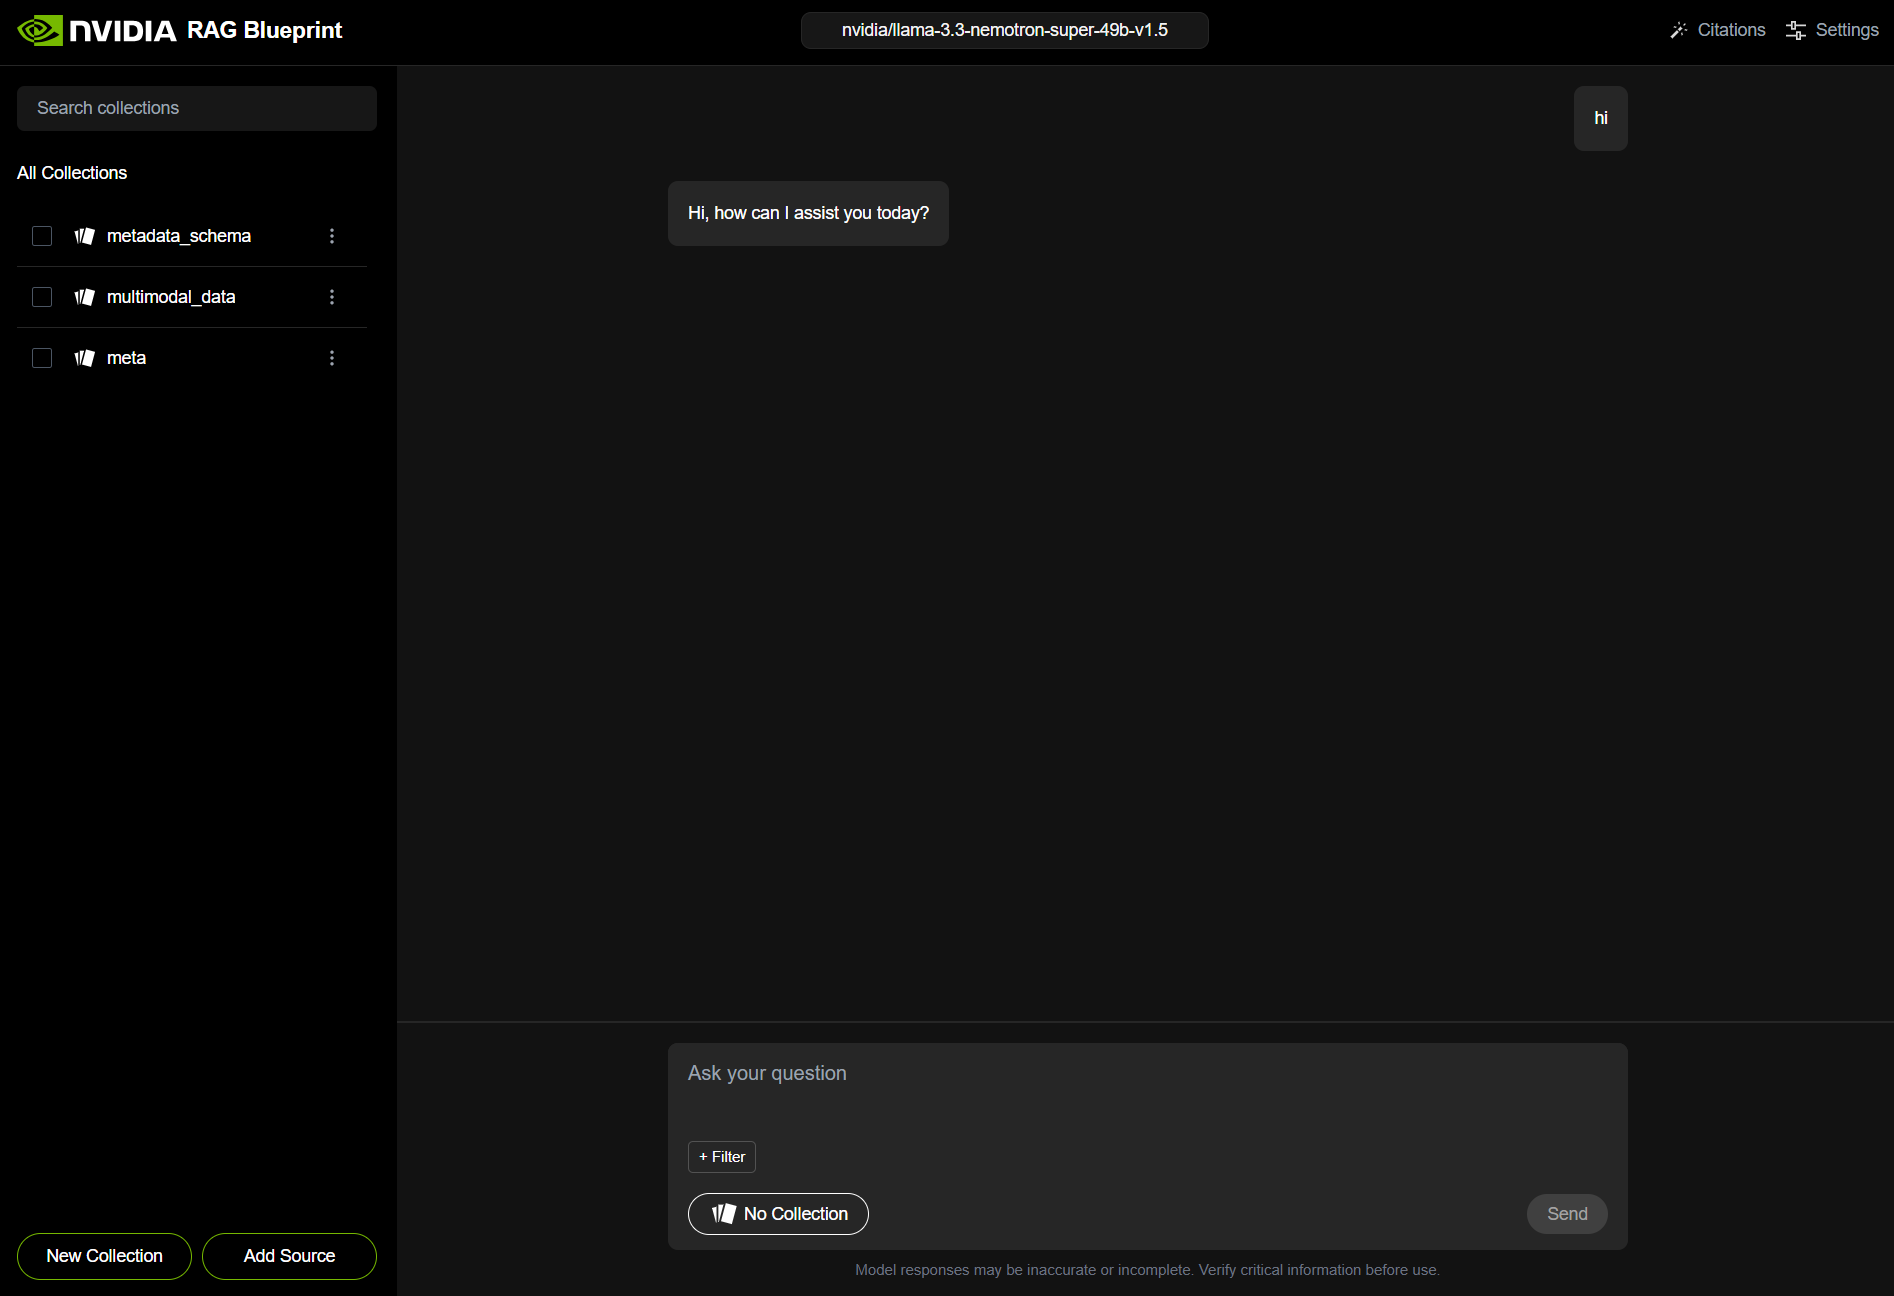

#### Testing the Chatbot

To evaluate how the RAG system works, try these experiments:

1. Create a new collection

2. Add source, then upload a document

3. Try asking a question about the document without selecting the new Collection (knowledge base off)

4. Ask a question with knowledge base on

**Ready to continue?** The rest of this notebook will show you how to programmatically interact with the RAG system through its API endpoints, giving you full control for integration into your applications.


---

## 3. Learning the Ingestion API

Now that all services are deployed, let's explore how to interact with the RAG system programmatically through its APIs. This section will demonstrate both the ingestion pipeline (adding documents to your knowledge base) and the basic query pipeline (asking questions without retrieving relevant information).

**What We'll Cover:**
1. **RAG Server API**: Query the system with natural language questions
2. **Document Ingestion API**: Upload and manage documents in the vector database  
3. **Document Retrieval & Reranking**: See how the system finds and ranks relevant information

**Two Key APIs:**
- **RAG Query Server** (Port 8081): The "front-end" for asking questions and getting answers
- **Ingestor Server** (Port 8082): The "back-end" for processing and storing documents

Think of the RAG Server as the interface users interact with, while the Ingestor Server handles the behind-the-scenes work of building the knowledge base.

### 3.1 Testing the Deployment

Before we ingest documents into our knowledge base, let's test that things are working in our deployment from Section 2. We will send a query to the RAG deployment without using the knowledge base, and we expect to get back an answer. 

#### 3.1.1 Test the OpenAI-compatible /chat/completions endpoint
The RAG Query Server is your main interface for interacting with the knowledge base. It exposes an OpenAI-compatible `/v1/chat/completions` endpoint that makes it easy to integrate into existing applications.

**Key Features:**
- **OpenAI-compatible API**: Use familiar request/response formats
- **Knowledge base toggle**: Turn retrieval on/off with `use_knowledge_base` parameter
- **Streaming responses**: Get responses token-by-token as the LLM generates them
- **Citation support**: Optionally include source document references

Let's test the endpoint to ensure our RAG server is responding correctly:

**3.1.1.1 RAG Server access.**

Here we will set up the configuration for the RAG server and a helper function to print the API responses.

In [ ]:
import requests
import json
import aiohttp

# IP address assuming all services are on the same docker network
IPADDRESS = "rag-server"

# Port number for the server
rag_server_port = "8081"

# Base URL constructed from IP and port for making API requests
RAG_BASE_URL = f"http://{IPADDRESS}:{rag_server_port}"

async def print_raw_response(response):
    """Helper function to print API responses.
    """
    try:
        response_json = await response.json()
        print(json.dumps(response_json, indent=2))
    except aiohttp.ClientResponseError:
        print(await response.text())

**3.1.1.2 Test the RAG server health endpoint and chat completion endpoint**

We will test both the health endpoint and chat completion functionality of our RAG server

- **Health Check Endpoint purpose:**
This endpoint performs a health check on the server. It returns a 200 status code if the server is operational.

- **Chat Completion Endpoint purpose:**
This endpoint accepts user queries and generates a response.


**Note:** We haven't uploaded any files into the RAG database yet. We are testing the endpoint _without_ RAG functionality. Just to make sure things so far are running properly.

```
"use_knowledge_base": False,  # Disable RAG functionality
```

In [ ]:
# 1. Test the RAG server health endpoint to verify it's running properly
url = f"{RAG_BASE_URL}/v1/health"
print("\nStep 1: Testing RAG server health endpoint")
print("-"*60)
async with aiohttp.ClientSession() as session:
    async with session.get(url) as response:
        await print_raw_response(response)

# 2. Test basic chat completion endpoint without using the knowledge base
payload = {
    "messages": [
        {
            "role": "user",
            "content": "Hi"  # Simple test message
        }
    ],
    "use_knowledge_base": False,  # Disable RAG functionality
    "temperature": 0.2,  # Lower temperature for more focused responses
    "model": os.environ["APP_LLM_MODELNAME"]
}

chat_url = f"{RAG_BASE_URL}/v1/chat/completions"

print("\nStep 2: Testing chat completion endpoint")
print("-"*60)
print("\nSending request to:", chat_url)
print("\nWith payload:", json.dumps(payload, indent=2))

async with aiohttp.ClientSession() as session:
    async with session.post(chat_url, json=payload) as response:
        await print_raw_response(response)

Great! Now, let's work on ingesting documents into our RAG pipeline. 

### 3.2 Document Ingestion API

The Ingestor Server manages the complete ingestion pipeline, converting raw documents to searchable embeddings. 

Tasks the Ingestor Server handles include:

- **Document Upload**: Add PDFs, text files, and other documents to your knowledge base
- **Multimodal Processing**: Extract text, tables, and images from complex documents
- **Automatic Chunking**: Split documents into optimal-sized pieces for retrieval
- **Embedding Generation**: Convert text chunks to vectors using NeMo Retriever Embedding NIM
- **Collection Management**: Organize documents into separate collections within the vector database.

**Main Endpoints:**
- `/v1/collections`: Create, list, and delete vector database collections
- `/v1/documents`: Upload, retrieve, and delete documents
- `/v1/health`: Check if the Ingestor server is running

**Important Configuration Parameters:**
- `vdb_endpoint`: Milvus vector database endpoint (default: `http://milvus:19530`)
- `collection_name`: Name of the collection to store documents
- `chunk_size`: Maximum tokens per document chunk (default: 1024)
- `chunk_overlap`: Overlapping tokens between chunks (default: 150)

Let's explore each endpoint in detail:



#### 3.2.1 Health Check Endpoint
**Purpose:**
This endpoint performs a health check on the server. It returns a 200 status code if the server is operational.

In [ ]:
# IP address assuming all services are on the same docker network
IPADDRESS = "ingestor-server"

# Port number for the server
ingestor_server_port = "8082"

# Base URL constructed from IP and port for making API requests
INGESTOR_BASE_URL = f"http://{IPADDRESS}:{ingestor_server_port}"

# Test the RAG server health endpoint to verify it's running properly
url = f"{INGESTOR_BASE_URL}/v1/health"
print("\nStep 1: Testing RAG server health endpoint")
print("-"*60)
async with aiohttp.ClientSession() as session:
    async with session.get(url) as response:
        await print_raw_response(response)

#### 3.2.2 Vector DB APIs Usage

**3.2.2.1 Create Collection Endpoint**

**Purpose:**
This endpoint is used to create a collection in the vector store. 

In [ ]:
async def create_collections(
    collection_names: list = None,
    collection_type: str = "text",
    embedding_dimension: int = 2048
):
    """Create one or more collections in the vector store.

    Args:
        collection_names (list): List of collection names to create
        collection_type (str): Type of collection, defaults to "text"
        embedding_dimension (int): Dimension of embeddings, defaults to 2048

    Returns:
        Response from the API endpoint or error details if request fails
    """
    # Parameters for creating collections
    params = {
        "vdb_endpoint": "http://milvus:19530",  # Milvus vector DB endpoint
        "collection_type": collection_type,      # Type of collection
        "embedding_dimension": embedding_dimension # Dimension of embeddings
    }

    HEADERS = {"Content-Type": "application/json"}

    # Make API request to create collections
    async with aiohttp.ClientSession() as session:
        try:
            async with session.post(f"{INGESTOR_BASE_URL}/v1/collections",
                                  params=params,
                                  json=collection_names,
                                  headers=HEADERS) as response:
                await print_raw_response(response)
        except aiohttp.ClientError as e:
            return 500, {"error": str(e)}

# Create a collection named "multimodal_data"
await create_collections(collection_names=["multimodal_data"])

**3.2.2.2 Get collections Endpoint**

**Purpose:**
This endpoint is used to get a list of collection names from the Milvus server. Returns a list of collection names.

In [ ]:
# First let's create another collection
await create_collections(collection_names=["multimodal_data1"])

# Now let's get the list of collections
async def fetch_collections():
    """Retrieve a list of all collections from the Milvus vector database.

    Makes a GET request to the ingestor API endpoint to fetch all collection names
    from the specified Milvus server.

    Returns:
        Response from the API endpoint containing the list of collections,
        or prints error message if request fails.
    """
    url = f"{INGESTOR_BASE_URL}/v1/collections"
    params = {"vdb_endpoint": "http://milvus:19530"}
    async with aiohttp.ClientSession() as session:
        try:
            async with session.get(url, params=params) as response:
                await print_raw_response(response)
        except aiohttp.ClientError as e:
            print(f"Error: {e}")

await fetch_collections()

**3.2.2.3 Delete collections Endpoint**

**Purpose:**
This endpoint deletes list of provided collection names available on the specified vector database server. You may want to do this for several reasons in your enterprise, such as managing stale data, data retention policies, or data privacy compliance.


In [ ]:
from typing import List

async def delete_collections(collection_names: List[str] = "") -> None:
    """Delete specified collections from the Milvus vector database.

    Makes a DELETE request to the ingestor API endpoint to remove the specified
    collections from the Milvus server.

    Args:
        collection_names (List[str]): List of collection names to delete.
            Defaults to empty string.

    Returns:
        None. Prints response from API or error message if request fails.

    Example:
        await delete_collections(collection_names=["collection1", "collection2"])
    """
    url = f"{INGESTOR_BASE_URL}/v1/collections"
    params = {"vdb_endpoint": "http://milvus:19530"}
    async with aiohttp.ClientSession() as session:
        try:
            async with session.delete(url, params=params, json=collection_names) as response:
                await print_raw_response(response)
        except aiohttp.ClientError as e:
            print(f"Error: {e}")

# Delete the collection from the previous section
print("\nDeleting collection 'multimodal_data1'...")
await delete_collections(collection_names=["multimodal_data1"])

# Fetch collections
print("\nFetching remaining collections:")
print("-" * 30)
await fetch_collections()

#### 3.2.3 Ingestion API Usage

**3.2.3.1 Upload Document Endpoint**

**Purpose:**
This endpoint uploads new documents to the vector store. 
1. You can specify the collection name where documents should be stored.

2. The collection must exist in the vector database before uploading documents.

3. Documents must not already exist in the collection. To update existing documents, use `session.patch(...)` instead of `session.post(...)`

4. Multiple files can be uploaded in a single request for efficiency

**Configuration Options:**

You can customize the document processing with these parameters:

- `split_options`: Define how documents are chunked (size, overlap).

  - Smaller chunk **size** allows for more precise semantic matching because each chunk can focus more effectively on a specific concept, but they may lose surrounding context. Larger chunk size preserve more context and relationships between concepts, but the additional content may dilute the semantic match score and include less relevant information.

  - Chunk **overlap** defines how much overlap exists between neighboring chunks which can help preserve context and continuity in the retrieved contents. 

- Custom metadata: Add additional information to your documents

**In this step, we'll upload the documents for ingestion.**

In [ ]:
# Directory containing multimodal documents to upload
DATA_DIR = "data/multimodal"

async def upload_documents(collection_name: str = "") -> None:
    """
    Uploads documents from DATA_DIR to the specified collection in the vector store.

    This function:
    1. Reads all files from DATA_DIR
    2. Configures extraction and chunking options
    3. Uploads documents via POST request to the documents endpoint

    Args:
        collection_name (str): Name of the collection to upload documents to.
                             Collection must exist before uploading.

    Extraction options:
        - Extracts text, tables and charts by default
        - Uses pdfium for extraction
        - Processes at page level granularity

    Chunking options:
        - chunk_size: 1024 tokens
        - chunk_overlap: 150 tokens

    """
    # Get list of files from DATA_DIR
    files = [os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if os.path.isfile(os.path.join(DATA_DIR, f))]

    # Configure upload parameters
    # Configure document processing parameters
    data = {
        # Milvus vector database endpoint
        "vdb_endpoint": "http://milvus:19530",

        # Target collection name for document storage
        "collection_name": collection_name,

        # Text chunking configuration
        "split_options": {
            "chunk_size": 1024,        # Size of each text chunk in tokens
            "chunk_overlap": 150       # Overlap between chunks in tokens
        }
    }

    # Prepare multipart form data with files and config
    form_data = aiohttp.FormData()
    for file_path in files:
        form_data.add_field("documents", open(file_path, "rb"), filename=os.path.basename(file_path), content_type="application/pdf")
    form_data.add_field("data", json.dumps(data), content_type="application/json")

    # Upload documents
    async with aiohttp.ClientSession() as session:
        try:
            async with session.post(f"{INGESTOR_BASE_URL}/v1/documents", data=form_data) as response: # Replace with session.patch for reingesting
                await print_raw_response(response)
        except aiohttp.ClientError as e:
            print(f"Error: {e}")

# Upload documents to the multimodal_data collection
await upload_documents(collection_name="multimodal_data")

**3.2.3.2 Delete Document Endpoint**

**Purpose:**
This endpoint removes specific documents from the vector store.

To demonstrate the functionality of this endpoint, we'll perform a complete document management workflow that includes uploading a new document in addition to the data already uploaded in the previous cell, checking for the updated database contents, before deleting the newly uploaded document:

* Create - a sample document/content to upload
* Upload - add the document to the vector store(`POST /v1/documents`)
* Verify - check that the document was ingested(`GET /v1/documents`)
* Delete - remove the document from the vector store(`DELETE /v1/documents`)

This workflow demonstrates the full lifecycle of document management in the RAG system, allowing you to update your knowledge base as needed.

In [ ]:
import tempfile

# Step 1. Create a sample text document
sample_text = """This is a sample text document.
It contains multiple lines of text.
This will be uploaded to the vector store for retrieval."""

# Create temporary text file
with tempfile.NamedTemporaryFile(mode='w+', suffix='.txt', delete=False) as temp_file:
    temp_file.write(sample_text)
    temp_file_path = temp_file.name

try:
    data = {
        "vdb_endpoint": "http://milvus:19530",
        "collection_name": "multimodal_data",

        # Text chunking configuration
        "split_options": {
            "chunk_size": 1024,
            "chunk_overlap": 150
        }
    }

    # Step 2. Upload file
    form_data = aiohttp.FormData()
    form_data.add_field("documents", open(temp_file_path, "rb"),
                       filename="sample_document.txt",
                       content_type="text/plain")
    form_data.add_field("data", json.dumps(data), content_type="application/json")

    async with aiohttp.ClientSession() as session:
        try:
            async with session.post(f"{INGESTOR_BASE_URL}/v1/documents", data=form_data) as response:
                await print_raw_response(response)
        except aiohttp.ClientError as e:
            print(f"Error: {e}")
finally:
    # Clean up the temporary file
    os.unlink(temp_file_path)

Wait a moment (~20s) for the document to upload successfully. 

**Now fetch the documents to verify ingestion, and then delete the document.**

In [ ]:
# Step 3: Fetch documents to verify ingestion
async def fetch_documents(collection_name: str = ""):
    url = f"{INGESTOR_BASE_URL}/v1/documents"
    params = {"collection_name": collection_name, "vdb_endpoint": "http://milvus:19530"}
    async with aiohttp.ClientSession() as session:
        try:
            async with session.get(url, params=params) as response:
                await print_raw_response(response)
        except aiohttp.ClientError as e:
            print(f"Error: {e}")

await fetch_documents(collection_name="multimodal_data")

# Step 4: Delete the test document
async def delete_documents(collection_name: str = "", file_names: List[str] = []):
    url = f"{INGESTOR_BASE_URL}/v1/documents"
    params = {"collection_name": collection_name, "vdb_endpoint": "http://milvus:19530"}
    async with aiohttp.ClientSession() as session:
        try:
            async with session.delete(url, params=params, json=file_names) as response:
                await print_raw_response(response)
        except aiohttp.ClientError as e:
            print(f"Error: {e}")

await delete_documents(collection_name="multimodal_data", file_names=["sample_document.txt"])

---

## 4. Sample Workflow: RAG-On vs. RAG-Off

Now that all services are deployed, let's see the RAG system in action! This section demonstrates the power of retrieval-augmented generation by comparing responses **with** and **without** access to the knowledge base.

### Why Compare With and Without RAG?

The comparison reveals:
- **Hallucination Prevention**: See how grounding in documents prevents the LLM from making up information
- **Knowledge Updates**: Observe how RAG provides information beyond the LLM's training cutoff date
- **Source Attribution**: Understand how RAG can cite specific sources for answers
- **Accuracy Improvement**: Watch factual accuracy increase when relevant context is provided

### How to Interact

You have two options for testing:

**1. Through the Playground UI** (Visual Interface)
- Interactive chatbot interface
- Easy document upload
- Toggle knowledge base on/off
- Real-time response streaming
- See [Section 2.9](#2.9-Access-the-RAG-Playground) for access instructions

**2. Through the API** (Programmatic Access)
- Full control over parameters
- Integration into applications
- Batch processing capabilities
- We'll focus on this approach below

### Key API Parameters

When calling `/v1/chat/completions`, important parameters include:

| Parameter | Purpose | Values |
|-----------|---------|--------|
| `use_knowledge_base` | Enable/disable RAG | `true` / `false` |
| `collection_name` | Which collection to search | e.g., `"multimodal_data"` |
| `vdb_top_k` | Number of chunks to retrieve | e.g., `100` |
| `reranker_top_k` | Number of chunks after reranking | e.g., `10` |
| `enable_reranker` | Use reranking for better relevance | `true` / `false` |
| `enable_citations` | Include source references | `true` / `false` |
| `temperature` | LLM creativity (0=focused, 1=creative) | `0.0` - `1.0` |
| `max_tokens` | Maximum response length | e.g., `1024` |

### Testing Approach

We'll ask the same question **twice**:
1. **Without RAG** (`use_knowledge_base: false`): See what the base LLM knows
2. **With RAG** (`use_knowledge_base: true`): See how retrieved context improves the answer

The question will be about information in our uploaded document that the LLM wouldn't know from its training data.

### 4.1 Setting Up API Interaction

First, let's create a utility function to handle streaming responses from the RAG server. This is particularly important because the LLM generates text token by token, and the API can stream these tokens as they're generated. We learned in the previous notebook the ability of LLMs to generate asynchronous responses all at once as well as real-time streamed responses. Here's our chance to put that into practice!


#### 4.1.1 Streaming Response Handler
This function processes the server's streaming response format, concatenating tokens to form the complete response:



In [ ]:
async def generate_answer(payload):
    """
    Asynchronously generates an answer from the RAG server by sending a POST request with the given payload.

    This function handles both streaming and non-streaming responses from the server.
    For streaming responses (text/event-stream), it concatenates the content from multiple chunks.
    For regular JSON responses, it extracts the content directly from the response.

    Args:
        payload (dict): The request payload containing messages and other parameters for the RAG server

    Returns:
        None: Prints the generated content to stdout

    The function expects the response to be in one of two formats:
    1. Streaming response with Server-Sent Events (SSE)
    2. Regular JSON response with a choices->message->content structure
    """
    async with aiohttp.ClientSession() as session:
        async with session.post(url=url, json=payload) as response:
            # Check if we're getting a streaming response
            content_type = response.headers.get('Content-Type', '')

            if 'text/event-stream' in content_type:
                # Handle streaming response
                response_text = await response.text()
                concatenated_content = ""

                for line in response_text.split('\n'):
                    if line.startswith('data: '):
                        json_str = line[len('data: '):]
                        if json_str.strip() == '[DONE]':
                            continue
                        try:
                            json_obj = json.loads(json_str)
                            content = json_obj.get("choices", [{}])[0].get("delta", {}).get("content", "")
                            concatenated_content += content
                        except json.JSONDecodeError:
                            continue

                print(concatenated_content)
            else:
                # Handle regular JSON response
                response_json = await response.json()
                if "error" in response_json:
                    print(f"Error: {response_json['error']}")
                    return

                content = response_json.get("choices", [{}])[0].get("message", {}).get("content", "")
                print(content)

#### 4.1.2 Test Endpoint Health
Verify the health of the RAG server:

In [ ]:
import aiohttp
# Testing RAG Server health
print("\nStep 1: Testing RAG server health endpoint")
print("-"*60)
async with aiohttp.ClientSession() as session:
    async with session.get(f"{RAG_BASE_URL}/v1/health") as response:
        await print_raw_response(response)

### 4.2 Preparing Test Document(s)
To demonstrate the difference between standard LLM responses and RAG-enhanced responses, we'll ingest a document containing information about a recent released TV show, The White Lotus, in which season 3 of the show was released in 2025. 

The LLM used in this notebook is based on the pretrained Llama 3.3 70B model from Meta, which has a pretraining cutoff date in December of 2023. This means it does not have up-to-date information about this particular TV show.

This will allow us to compare how the system responds to queries with and without access to this knowledge since the LLM does not have knowledge of this particular season in its pretrained knowledge. 

#### 4.2.1 Downloading the Sample Document
First, let's download a sample document about about a recent show from wikipedia.

In [ ]:
!curl -L "https://en.wikipedia.org/api/rest_v1/page/pdf/The_White_Lotus_season_3" -o The_White_Lotus_Season_3.pdf

#### 4.2.2 Ingest Document into Knowledge Base
Now we need to process this document and add it to our vector database:


In [ ]:
# IP address assuming all services are on the same docker network
IPADDRESS = "ingestor-server"

# Port number for the server
rag_server_port = "8082"

# Base URL constructed from IP and port for making API requests
INGESTOR_BASE_URL = f"http://{IPADDRESS}:{rag_server_port}"
SAMPLE_DOCUMENT = "The_White_Lotus_Season_3.pdf"

# Upload FIFA World Cup Winners PDF
async def upload_sample_document(collection_name: str = "") -> None:
    sample_pdf_path = SAMPLE_DOCUMENT

    data = {
        "vdb_endpoint": "http://milvus:19530",
        "collection_name": collection_name,
        "split_options": {
            "chunk_size": 1024,
            "chunk_overlap": 150
        }
    }

    form_data = aiohttp.FormData()
    form_data.add_field("documents",
                       open(sample_pdf_path, "rb"),
                       filename=SAMPLE_DOCUMENT,
                       content_type="application/pdf")
    form_data.add_field("data", json.dumps(data))

    async with aiohttp.ClientSession() as session:
        try:
            async with session.post(f"{INGESTOR_BASE_URL}/v1/documents", data=form_data) as response:
                await print_raw_response(response)
        except aiohttp.ClientError as e:
            print(f"Error: {e}")

await upload_sample_document(collection_name="multimodal_data")

Wait a moment (~20s) for the document to upload successfully.

### 4.3 Comparing LLM vs. RAG Responses
Now let's compare how the system responds to the same query with and without leveraging the knowledge base.

#### 4.3.1 Query **Without** Knowledge Base
First, let's see how the model responds using only its pre-trained knowledge. At the time of authoring this notebook, the pre-trained LLM did not have knowledge of this newly released show.

In [ ]:
# IP address assuming all services are on the same docker network
IPADDRESS = "rag-server"

# Port number for the server
rag_server_port = "8081"

# Base URL constructed from IP and port for making API requests
RAG_BASE_URL = f"http://{IPADDRESS}:{rag_server_port}"  # Replace with your server URL

url = f"{RAG_BASE_URL}/v1/chat/completions"
payload = {
  "messages": [
    {
      "role": "user",
      "content": "Who is Nicholas Duvernay's character related to?"
    }
  ],
  "use_knowledge_base": False,
  "temperature": 0.2,
  "top_p": 0.7,
  "max_tokens": 1024,
  "reranker_top_k": 10,
  "vdb_top_k": 100,
  "vdb_endpoint": "http://milvus:19530",
  "collection_name": "multimodal_data",
  "enable_query_rewriting": False,
  "enable_reranker": True,
  "enable_guardrails": False,
  "enable_citations": True,
  "model": os.environ["APP_LLM_MODELNAME"],
  "llm_endpoint": "https://integrate.api.nvidia.com/v1/chat/completions",
  "embedding_model": "nvidia/llama-3.2-nv-embedqa-1b-v2",
  "reranker_model": "nvidia/llama-3.2-nv-rerankqa-1b-v2",
  "stop": [],
}

await generate_answer(payload)

**What's happening:**

> - The request sets use_knowledge_base: false
>
> - The model relies solely on its pre-trained knowledge
> - No document retrieval or context augmentation occurs 
> - The response is based on what the model "knows" from training
> - For recent or specialized information, this may lead to outdated or incorrect answers

#### 4.3.2 Query **With** Knowledge Base (RAG)

**How It Works:**
When you send a query with `use_knowledge_base: true`, the RAG server:
1. Converts your question into an embedding using the NeMo Retriever Embedding NIM
2. Searches Milvus for the most semantically similar document chunks
3. Optionally reranks results for improved relevance
4. Injects retrieved context into the LLM prompt
5. Calls the Nemotron Reasoning NIM to generate the final answer
6. Returns the response (optionally with citations)

Now, let's run the same query but enable the knowledge base:


In [ ]:
# IP address assuming all services are on the same docker network
IPADDRESS = "rag-server"

# Port number for the server
rag_server_port = "8081"

# Base URL constructed from IP and port for making API requests
RAG_BASE_URL = f"http://{IPADDRESS}:{rag_server_port}"

url = f"{RAG_BASE_URL}/v1/chat/completions"
payload = {
  "messages": [
    {
      "role": "user",
      "content": "Who is Nicholas Duvernay's character related to?"
    }
  ],
  "use_knowledge_base": True,
  "temperature": 0.2,
  "top_p": 0.7,
  "max_tokens": 1024,
  "reranker_top_k": 10,
  "vdb_top_k": 100,
  "vdb_endpoint": "http://milvus:19530",
  "collection_name": "multimodal_data",
  "enable_query_rewriting": False,
  "enable_reranker": True,
  "enable_guardrails": False,
  "enable_citations": True,
  "model": os.environ["APP_LLM_MODELNAME"],
  "llm_endpoint": "https://integrate.api.nvidia.com/v1/chat/completions",
  "embedding_model": "nvidia/llama-3.2-nv-embedqa-1b-v2",
  "reranker_model": "nvidia/llama-3.2-nv-rerankqa-1b-v2",
  "stop": []
}

await generate_answer(payload)

**What's happening:**

> - The request sets use_knowledge_base: true
>
> - The system converts the query into an embedding
> - It searches the vector database for semantically similar document chunks
> - The retrieved chunks are added as context to the LLM prompt
> - The model generates a response based on this augmented context
> - The response should contain specific information from our ingested document

---

## 5. Understanding Document Retrieval and Reranking 

In the previous section, you saw RAG in action. Now let's dive deeper into **how** the system finds relevant information. Let's do one final workflow where we dive deep into understanding the document retrieval and reranking process that is underpinning the RAG workflow you just experienced in Section 4.

### The Two-Stage Retrieval Process

RAG uses a two-stage approach to find the most relevant information:

#### Stage 1: Vector Similarity Search (Retrieval)
```
Query → Embedding → Search Milvus → Top 100 Chunks
```

1. **Convert query to embedding**: Your question becomes a 2048-dimensional vector
2. **Search vector database**: Find chunks with similar embeddings (semantic similarity)
3. **Return top-k results**: Retrieve the 100 most similar chunks (configurable via `vdb_top_k`)

**Why This Works:**
- Embeddings capture meaning, not just keywords
- "How do plants make food?" matches "photosynthesis process" semantically
- Fast approximate search scales to billions of vectors

**Limitation:**
- Initial retrieval prioritizes speed over perfect relevance
- Some results may be semantically similar but contextually less relevant

#### Stage 2: Reranking (Relevance Refinement)
```
Top 100 Chunks → Reranker Model → Top 10 Best Chunks
```

1. **Deep analysis**: Reranker model examines each chunk more carefully
2. **Contextual scoring**: Evaluates how well each chunk answers the specific question
3. **Reorder results**: Sorts by relevance, not just semantic similarity
4. **Select top-k**: Returns the 10 most relevant chunks (configurable via `reranker_top_k`)

**Why This Works:**
- Reranker uses a different model specialized for relevance
- Deeper analysis considers context and question-answering fit
- Smaller set of chunks means more computation per chunk is feasible

**The Trade-off:**
- Retrieval: Fast but broad (cast a wide net)
- Reranking: Slower but precise (refine the results)

### Retrieval vs. Reranking Comparison

| Aspect | Vector Retrieval | Reranking |
|--------|-----------------|-----------|
| **Speed** | Very fast (milliseconds) | Slower (needs compute per chunk) |
| **Method** | Vector similarity (cosine distance) | Cross-encoder model |
| **Coverage** | Broad (casts wide net) | Narrow (refines results) |
| **Typical Count** | 100+ chunks | 10-20 chunks |
| **Focus** | Semantic similarity | Question-answering relevance |
| **Model** | Embedding model | Reranking model |

### Why Use Both?

The two-stage approach optimizes for both **recall** and **precision**:

1. **High Recall (Retrieval)**: Cast a wide net to ensure relevant chunks aren't missed
2. **High Precision (Reranking)**: Refine results to surface the most relevant chunks first

Think of it like:
- **Retrieval** = Google search (returns many results)
- **Reranking** = Reading top results to find the best answer

### Testing the Retrieval Pipeline

In the cells below, we'll:
1. **Query without reranking**: See raw vector similarity results
2. **Query with reranking**: Observe how relevance scores and order improve
3. **Compare results**: Understand the impact of each stage

This will give you insight into how the RAG pipeline finds and ranks information before passing it to the LLM for answer generation.

### 5.1 Utility function to print search results
First, let's create a utility function to better visualize search results:


In [ ]:
def print_search_results(response):
    """
    Nicely formats and prints search results from the RAG system.
    Also renders base64 encoded images when present.

    Args:
        response (dict): The response from the search API

    Returns:
        None: Prints formatted results to the console and displays images when applicable
    """
    if 'results' not in response or 'total_results' not in response:
        print("Invalid response format or no results found.")
        return

    print(f"\n=== SEARCH RESULTS ({response['total_results']} total) ===\n")

    for i, result in enumerate(response['results'], 1):
        print(f"Result #{i}")
        print(f"Document: {result.get('document_name', 'Unknown')}")
        print(f"Score: {result.get('score')}")

        # Handle different document types
        document_type = result.get('document_type', 'text')
        print(f"Type: {document_type}")

        print("\nContent:")
        print("-" * 80)

        content = result.get('content', '')

        # Check if content looks like base64 image data
        # Base64 images typically start with specific patterns
        is_likely_image = False
        if content and isinstance(content, str):
            # Common base64 image prefixes to check
            image_prefixes = ['iVBOR', '/9j/', 'R0lGOD', 'PD94', 'PHN2']
            is_likely_image = any(content.startswith(prefix) for prefix in image_prefixes)

        # For chart/image type documents or content that looks like base64
        if document_type in ['chart', 'image'] or is_likely_image:
            try:
                import base64
                from PIL import Image
                import io
                from IPython.display import display

                # Get base64 string and decode
                img_data = base64.b64decode(content)

                # Convert to PIL Image
                img = Image.open(io.BytesIO(img_data))

                # Display the image
                display(img)

                # Print metadata description if available
                if 'metadata' in result and 'description' in result['metadata']:
                    print(f"\nDescription: {result['metadata']['description']}")
            except Exception as e:
                print(f"Error rendering image: {str(e)}")
                print("Raw content (base64 encoded, truncated):")
                if len(content) > 100:
                    content = content[:100] + "... [base64 content truncated]"
                print(content)
        else:
            # For text documents, print the content with optional truncation
            if len(content) > 500:
                content = content[:500] + "... [content truncated]"
            print(content)

        print("-" * 80)
        print("\n")

### 5.2 Basic Search Without Reranking
Let's perform a basic search query without reranking:


In [ ]:
# Search without ranking
url = f"{RAG_BASE_URL}/v1/search"
payload={
  "query": "What is the rationale for Clear Print Guidelines",
  "reranker_top_k": 3,
  "vdb_top_k": 100,
  "vdb_endpoint": "http://milvus:19530",
  "collection_name": "multimodal_data",
  "messages": [
    {
      "role": "user",
      "content": "What is the rationale for Clear Print Guidelines"
    }
  ],
  "enable_query_rewriting": False,
  "enable_reranker": False,
  "embedding_model": "nvidia/llama-3.2-nv-embedqa-1b-v2",
  "reranker_model": "nvidia/llama-3.2-nv-rerankqa-1b-v2",
}

async def document_search(payload):
    """
    Performs a search against the RAG system and prints formatted results.

    Args:
        payload (dict): The search query payload

    Returns:
        dict: The raw response from the API
    """
    async with aiohttp.ClientSession() as session:
        try:
            async with session.post(url=url, json=payload) as response:
                response_json = await response.json()
                print_search_results(response_json)  # Format and print the results
                return None  # Still return the response but it won't be printed
        except aiohttp.ClientError as e:
            print(f"Error: {e}")
            return None

await document_search(payload)

### 5.3 Enhanced Search With Reranking
Now let's see how reranking improves search results.

In [ ]:
# Search with ranking
url = f"{RAG_BASE_URL}/v1/search"
payload={
  "query": "What is the rationale for Clear Print Guidelines",
  "reranker_top_k": 3,
  "vdb_top_k": 100,
  "vdb_endpoint": "http://milvus:19530",
  "collection_name": "multimodal_data",
  "messages": [
    {
      "role": "user",
      "content": "What is the rationale for Clear Print Guidelines"
    }
  ],
  "enable_query_rewriting": False,
  "enable_reranker": True,
  "embedding_model": "nvidia/llama-3.2-nv-embedqa-1b-v2",
  "reranker_model": "nvidia/llama-3.2-nv-rerankqa-1b-v2",
}

async def document_search(payload):
    """
    Performs a search against the RAG system and prints formatted results.

    Args:
        payload (dict): The search query payload

    Returns:
        dict: The raw response from the API
    """
    async with aiohttp.ClientSession() as session:
        try:
            async with session.post(url=url, json=payload) as response:
                response_json = await response.json()
                print_search_results(response_json)  # Format and print the results
                return None  # Still return the response but it won't be printed
        except aiohttp.ClientError as e:
            print(f"Error: {e}")
            return None

await document_search(payload)

**What's happening:**

> - Initial retrieval is performed using vector similarity (same as basic search)
>
> - The reranker model then examines each retrieved document more carefully
> - It scores the relevance of each document to the specific query
> - Results are reordered based on these relevance scores
> - The most relevant documents appear at the top

Notice how the scores change and how the ordering of results differ with the Reranker turned ON vs OFF.

### 5.4 Delete the uploaded sample document

In [ ]:
await delete_documents(collection_name="multimodal_data", file_names=[SAMPLE_DOCUMENT])

## Additional Exercises
Now that you have deployed and tested the RAG system, here are some suggested next steps:

 - Upload your own documents: Try ingesting different document types (PDFs, text files, etc.)

 - Experiment with parameters: Adjust temperature, top_k values, and other settings

 - Compare quality: Set up side-by-side comparisons of RAG vs. non-RAG responses

 - Integrate with applications: Use the APIs to build your own applications on top of this system
 
 - Custom prompt engineering: Experiment with different prompt formats to improve response quality

The system you've deployed provides a powerful foundation for building AI-powered applications that can leverage both the knowledge in your documents and the capabilities of large language models.

To stop the blueprint services, uncomment and execute the following cell block

In [ ]:
# %%capture
# !docker compose -f deploy/compose/vectordb.yaml down
# !docker compose -f deploy/compose/docker-compose-ingestor-server.yaml down
# !docker compose -f deploy/compose/docker-compose-rag-server.yaml down

---

## 6. (Optional) Local / On-Prem Deployment

The following are instructions for a local, on-prem deployment of this NVIDIA NIM. Due to compute limitations, we will utilize the free NVIDIA-hosted endpoints from above for this course, but these code snippets are provided here as reference for developers interested in spinning up their own endpoints on their own GPU infrastructure. 

#### Authenticate and Configure

For the ``nvidia/llama-3_3-nemotron-super-49b-v1_5`` reasoning model, you will need at least 2x A100 or H100 GPUs. 

```bash
# Authenticate into Docker
export NGC_API_KEY=nvapi-...
echo "${NGC_API_KEY}" | docker login nvcr.io -u '$oauthtoken' --password-stdin

# Make a writeable local NIM cache
mkdir -p ~/.cache/model-cache
export MODEL_DIRECTORY=~/.cache/model-cache

# Set the environment variables
source deploy/compose/.env
export LLM_MS_GPU_ID=1,2 # (Optional if using a larger model, eg. nvidia/llama-3_3-nemotron-super-49b-v1_5)
```


#### Deploy the Blueprint Locally

```bash
# spin up nims
docker compose -f deploy/compose/nims.yaml up -d

# spin up vectordb
docker compose -f deploy/compose/vectordb.yaml up -d

# spin up ingestor server
docker compose -f deploy/compose/docker-compose-ingestor-server.yaml up -d --build

# spin up rag server
docker compose -f deploy/compose/docker-compose-rag-server.yaml up -d --build
```

#### Wait for Readiness

```bash
docker ps --format "table {{.ID}}\t{{.Names}}\t{{.Status}}"
```

When the services are ready, you should see a total of 15 microservices. The output should look like this: 

```docker ps --format "table {{.ID}}\t{{.Names}}\t{{.Status}}"
CONTAINER ID   NAMES                            STATUS
01196e59cd6f   rag-server                       Up 42 seconds
578e86a6d526   ingestor-server                  Up About a minute
26b0a6b9ecb9   compose-nv-ingest-ms-runtime-1   Up 3 minutes (healthy)
b69c68b9dd09   compose-redis-1                  Up 5 minutes
62a6734d53d3   milvus-standalone                Up 6 minutes
ca56c4e07df1   milvus-minio                     Up 6 minutes (healthy)
892889cdc094   milvus-etcd                      Up 6 minutes (healthy)
bd77efb39b90   nim-llm-ms                       Up 8 minutes (healthy)
c84bfd73c118   nemoretriever-ranking-ms         Up 10 minutes (healthy)
df4a5a2aebfd   compose-graphic-elements-1       Up 10 minutes
e7d5593c27b8   compose-page-elements-1          Up 10 minutes
8619fd2d1012   compose-paddle-1                 Up 10 minutes
dbf4c4e96340   nemoretriever-embedding-ms       Up 10 minutes (healthy)
371639aee5ad   compose-table-structure-1        Up 10 minutes
ca6fe2dd51ce   rag-playground                   Up 42 seconds
```

---

## 🎓 Summary and Next Steps

**Congratulations!** You've successfully deployed a complete RAG pipeline and connected reasoning models to knowledge sources. Let's recap what you've learned:

### What We Covered

✅ **RAG Fundamentals**: Understood how retrieval augments generation for grounded responses  
✅ **RAG Architecture**: Explored the ingestion and query pipelines in depth  
✅ **Deployment**: Set up all microservices using NVIDIA-hosted endpoints  
✅ **Document Ingestion**: Processed and stored multimodal content in vector databases  
✅ **Knowledge-Based Queries**: Compared responses with and without knowledge base augmentation  
✅ **Semantic Retrieval**: Saw how embedding models enable semantic search  
✅ **Reranking**: Understood how reranking improves retrieval relevance  

### Key Takeaways

1. **RAG Solves Real Problems**: By connecting LLMs to knowledge bases, RAG addresses hallucinations, knowledge cutoffs, and enables citations

2. **Two-Phase System**: Ingestion happens once to build the knowledge base, while queries happen in real-time with retrieval

3. **Vector Embeddings Enable Semantic Search**: Converting text to vectors allows finding similar concepts even without keyword matches

4. **Multimodal Processing**: NV-Ingest handles PDFs with text, images, and tables through specialized NIMs

5. **Hybrid Deployment**: Using NVIDIA-hosted NIMs for compute with local infrastructure for data keeps costs low while maintaining control

6. **Production-Ready**: This blueprint provides enterprise-grade components ready for real applications

### What Makes This RAG System Powerful

The NVIDIA RAG Blueprint you deployed combines:

**State-of-the-Art Models:**
- Nemotron for reasoning and generation (previous notebook)
- NeMo Retriever for embeddings and reranking
- Specialized vision models for multimodal content

**Production Components:**
- Milvus for large-scale vector search
- NV-Ingest for robust document processing
- API servers for easy integration

**Enterprise Features:**
- Multimodal document support
- Configurable chunking strategies
- Optional reranking for improved accuracy
- Citation support for traceability

### Next: Build the Deep Research Agent

Now that you have a reasoning model (previous notebook) **and** a RAG pipeline (this notebook), you're ready to build the complete deep research agent!

In the next notebook, you'll learn to:
- **Chain multiple RAG queries** to answer complex questions
- **Use reasoning with retrieval** for multistep problem solving
- **Evaluate and verify** information from multiple sources via tool calling
- **Build the complete AI-Q Research Assistant** blueprint

The deep research agent combines everything you've learned so far into a single AI agent:
- Reasoning models break down complex questions
- RAG retrieves relevant information from documents
- Multistep workflows synthesize comprehensive answers

**Ready to complete your journey?** Open `04-Deploy-Researcher.ipynb` to build the full deep research agent! 🚀

<a href="https://www.nvidia.com/dli"> <img src="images/nvidia_header.png" style="margin-left: -30px; width: 300px; float: left;"> </a>